# Assignment 12: Neural Network and Deep Learning Basics
# Student Name: Mohammad Tamim Hamkar


## Step 1: Import Libraries

Here, I import the libraries needed to build, train, and evaluate the neural network.

In [1]:
# Import libraries for data processing and visualization
import numpy as np
import matplotlib.pyplot as plt

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Import tools for model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")
print("TensorFlow Version:", tf.__version__)

Libraries imported successfully.
TensorFlow Version: 2.20.0


## Step 2: Load the Fashion MNIST Dataset

Here, I load the Fashion MNIST dataset and check the size of the training and testing data.

In [2]:
# Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Display the dataset sizes
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## Step 3: Visualize Sample Images

Display one sample image from each Fashion MNIST category to better understand the dataset.

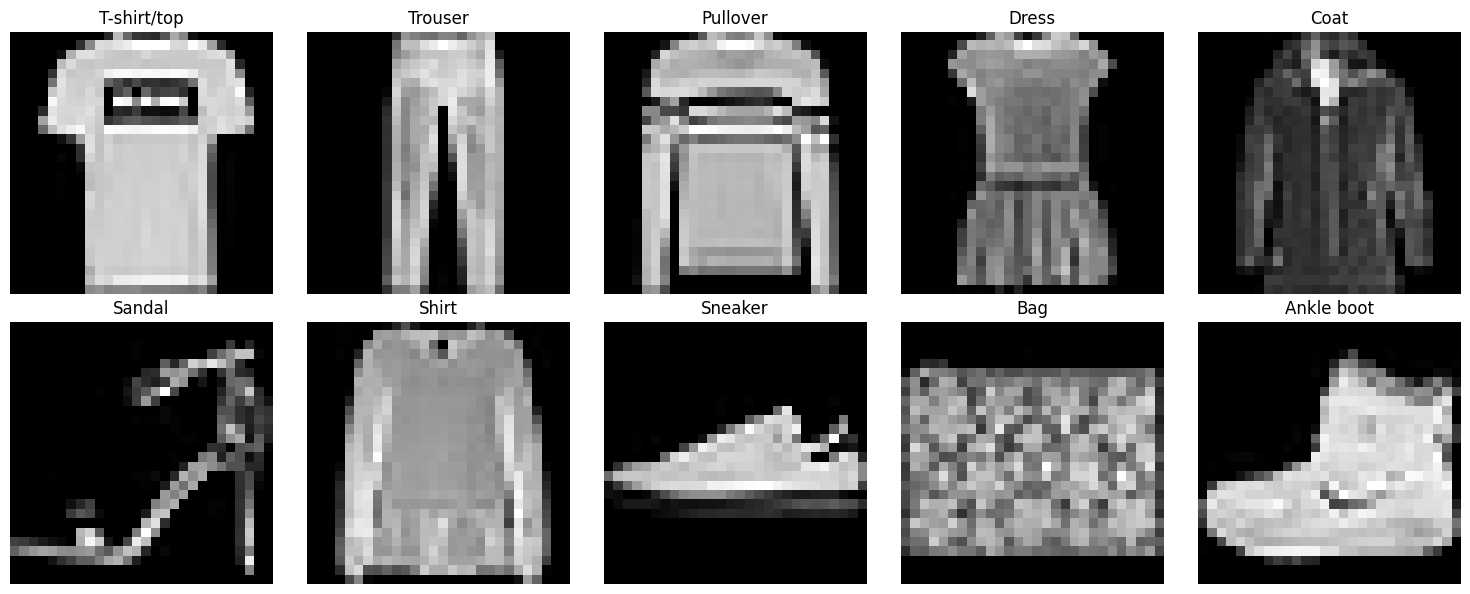

In [3]:
# Define the Fashion MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Display one sample image from each class
plt.figure(figsize=(15, 6))

for class_index in range(10):
    # Find the first image that belongs to this class
    image_index = np.where(y_train == class_index)[0][0]

    plt.subplot(2, 5, class_index + 1)
    plt.imshow(X_train[image_index], cmap="gray")
    plt.title(class_names[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Normalize the Images

Normalize the image pixel values from 0–255 to 0–1 to prepare the data for neural network training.

In [4]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Check the new pixel value range
print("Training pixel range:", X_train.min(), "to", X_train.max())
print("Testing pixel range:", X_test.min(), "to", X_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


## Step 5: Build the Neural Network

Here, I create a simple feedforward neural network with hidden layers using ReLU and a Softmax output layer.

In [6]:
# Create the feedforward neural network
model = Sequential([
    # Define the input shape
    tf.keras.Input(shape=(28, 28)),

    # Convert each 28x28 image into a one-dimensional vector
    Flatten(),

    # Hidden layers using ReLU activation
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # Output layer for the 10 image categories
    Dense(10, activation="softmax")
])

# Display the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Neural Network

Compile the model using the Adam optimizer and categorical crossentropy loss.

In [7]:
# Compile the neural network
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Step 7: Train the Neural Network

Train the model for 10 epochs and use part of the training data for validation.

In [8]:
# Train the neural network
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8178 - loss: 0.5178 - val_accuracy: 0.8545 - val_loss: 0.4132
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8630 - loss: 0.3785 - val_accuracy: 0.8662 - val_loss: 0.3691
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8765 - loss: 0.3408 - val_accuracy: 0.8658 - val_loss: 0.3778
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8829 - loss: 0.3180 - val_accuracy: 0.8683 - val_loss: 0.3470
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8898 - loss: 0.2974 - val_accuracy: 0.8827 - val_loss: 0.3274
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8953 - loss: 0.2806 - val_accuracy: 0.8744 - val_loss: 0.3377
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8984 - loss: 0.2710 - val_accuracy: 0.8857 - val_loss: 0.3268
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9026 - loss: 0.2571 - 

## Step 8: Visualize Training Results

Compared the training and validation accuracy and loss to see how the model improved during training.

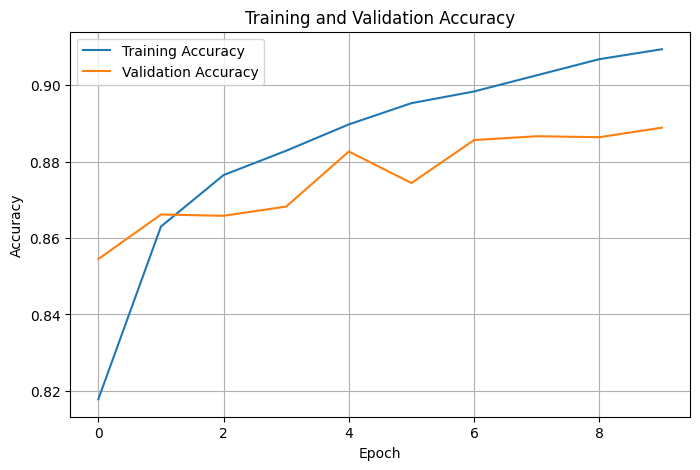

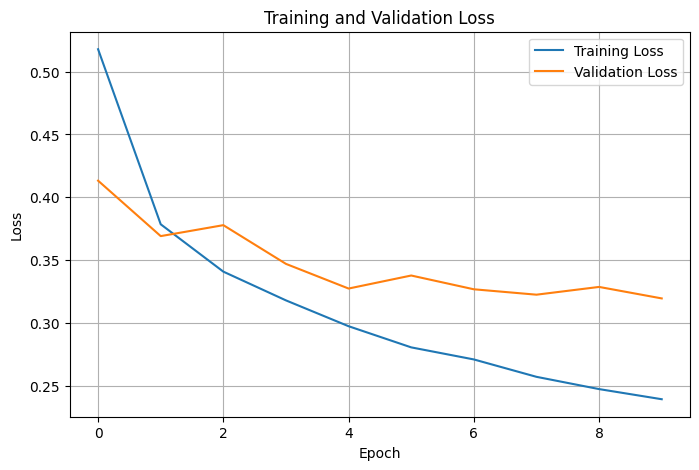

In [9]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Step 9: Evaluate the Model

Here, I test the trained model and calculate accuracy, precision, recall, and F1-score.

In [10]:
# Make predictions on the test images
y_prob = model.predict(X_test)

# Convert prediction probabilities to class labels
y_pred = np.argmax(y_prob, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Display the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.8816
Precision: 0.8843729539261103
Recall: 0.8816
F1 Score: 0.8805277339405695


## Step 10: Classification Report and Confusion Matrix

checking how well the model performed for each clothing category and visualize the results using a confusion matrix.

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.88      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.83      0.73      0.78      1000
       Dress       0.90      0.87      0.88      1000
        Coat       0.71      0.90      0.79      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.77      0.62      0.69      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



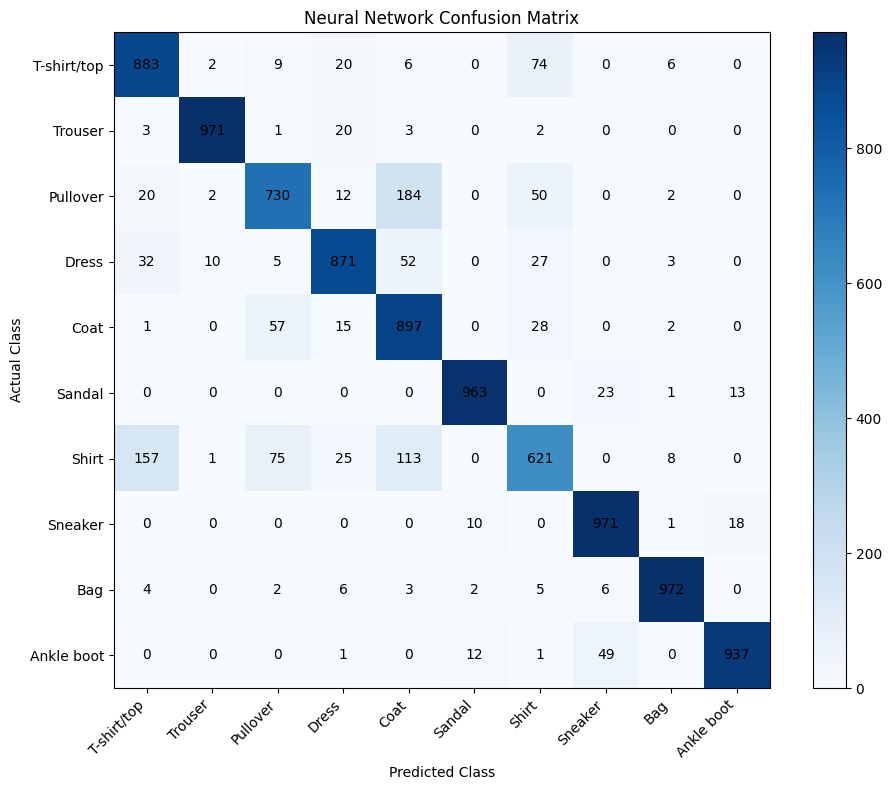

In [11]:
# Display the classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Neural Network Confusion Matrix")
plt.colorbar()

# Add class labels
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)

# Add values inside the matrix
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## Step 11: Improve the Neural Network

Here, I try a larger neural network with different layer sizes to see if the model performance improves.

In [12]:
# Create an improved neural network with larger hidden layers
improved_model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),

    # Larger hidden layers
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # Output layer
    Dense(10, activation="softmax")
])

# Compile the improved model
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the improved model
improved_history = improved_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8176 - loss: 0.5085 - val_accuracy: 0.8402 - val_loss: 0.4348
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8626 - loss: 0.3756 - val_accuracy: 0.8738 - val_loss: 0.3591
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8758 - loss: 0.3356 - val_accuracy: 0.8727 - val_loss: 0.3548
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8835 - loss: 0.3137 - val_accuracy: 0.8736 - val_loss: 0.3475
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8921 - loss: 0.2926 - val_accuracy: 0.8793 - val_loss: 0.3442
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8947 - loss: 0.2796 - val_accuracy: 0.8792 - val_loss: 0.3347
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8991 - loss: 0.2672 - val_accuracy: 0.8845 - val_loss: 0.3202
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9053 - loss: 0.2527 -

## Step 12: Evaluate and Compare the Improved Model

Here, I evaluate the improved model and compare its performance with the original model.

In [13]:
# Make predictions using the improved model
improved_prob = improved_model.predict(X_test)
improved_pred = np.argmax(improved_prob, axis=1)

# Calculate evaluation metrics
improved_accuracy = accuracy_score(y_test, improved_pred)
improved_precision = precision_score(y_test, improved_pred, average="weighted")
improved_recall = recall_score(y_test, improved_pred, average="weighted")
improved_f1 = f1_score(y_test, improved_pred, average="weighted")

# Display the improved model results
print("Improved Model Results:")
print("Accuracy:", improved_accuracy)
print("Precision:", improved_precision)
print("Recall:", improved_recall)
print("F1 Score:", improved_f1)

# Compare accuracy with the original model
print("\nOriginal Model Accuracy:", accuracy)
print("Improved Model Accuracy:", improved_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Improved Model Results:
Accuracy: 0.8768
Precision: 0.8770720884412132
Recall: 0.8768
F1 Score: 0.874461179535383

Original Model Accuracy: 0.8816
Improved Model Accuracy: 0.8768


## Step 13: Model Comparison

The original model achieved 88.16% test accuracy, while the larger model achieved 87.68%. This shows that adding more layers and neurons did not improve the results in this experiment. The original model performed slightly better on the Fashion MNIST test data.